# Using KNN to Classify Dry Bean Varities

In this notebook, we use a KNN classifier to classify seven different types of dry beans using their physical measurements and features as predictor variables. The [Dry Bean dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) comes from UC Irvine's Machine Learning Repository.

This dataset contains 13,611 bean grain images from seven registered Turkish varieties: Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, and Sira. From each image, 16 geometric and shape features were extracted — 12 dimensional measurements and 4 shape-form descriptor. Descriptions of each feature can be found through the link above. 


**Features (16 total):** Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio, Eccentricity, ConvexArea, EquivDiameter, Extent, Solidity, Roundness, Compactness, ShapeFactor(1-4)

**Target:** Class — 7 bean varieties


This classification problem, and features involved (such as MajorAxisLength and ConvexArea), is similar to the raisin binary classification problem from the Logistic Regression examples folder. This will be an interesting way to see how our package's classification algorithms handle a multiple classification problem.

---

# Load and Explore Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from ml_package import (
    KNN,
    StandardScaler,
    train_test_split,
    classification_metrics,
)

np.random.seed(42)

In [11]:
# Load data and assign features and target
df = pd.read_csv("Dry_Bean_Dataset.csv")
X = df.drop(columns = "Class")
y = df["Class"]

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [15]:
# Descriptive statistics
X.describe().round(3)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751,53768.200,253.064,0.750,0.987,0.873,0.800,0.007,0.002,0.644,0.995
std,29324.096,214.290,85.694,44.970,0.247,0.092,29774.916,59.177,0.049,0.005,0.060,0.062,0.001,0.001,0.099,0.004
min,20420.000,524.736,183.601,122.513,1.025,0.219,20684.000,161.244,0.555,0.919,0.490,0.641,0.003,0.001,0.410,0.948
25%,36328.000,703.524,253.304,175.848,1.432,0.716,36714.500,215.068,0.719,0.986,0.832,0.762,0.006,0.001,0.581,0.994
50%,44652.000,794.941,296.883,192.432,1.551,0.764,45178.000,238.438,0.760,0.988,0.883,0.801,0.007,0.002,0.642,0.996
75%,61332.000,977.213,376.495,217.032,1.707,0.810,62294.000,279.446,0.787,0.990,0.917,0.834,0.007,0.002,0.696,0.998
max,254616.000,1985.370,738.860,460.198,2.430,0.911,263261.000,569.374,0.866,0.995,0.991,0.987,0.010,0.004,0.975,1.000


---

The Counter of class labels shows that the target classes are moderately imbalanced, with Dermosan and Sira having many more samples than Bombay. This moderate imbalance is relevant because it slightly biases accuracy toward the majority class; macro-averaged F1 will probably be a fairer summary metric.

---

In [14]:
# Data shape and class balance
print(f"Shape: {X.shape}  |  Classes: {np.unique(y)}")
print(f"Class balance: { Counter(y) }")

Shape: (13611, 16)  |  Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Class balance: Counter({'DERMASON': 3546, 'SIRA': 2636, 'SEKER': 2027, 'HOROZ': 1928, 'CALI': 1630, 'BARBUNYA': 1322, 'BOMBAY': 522})


C:\Users\Owinf\AppData\Local\Temp\ipykernel_34880\3522157445.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class, labels=classes, patch_artist=True, notch=False)


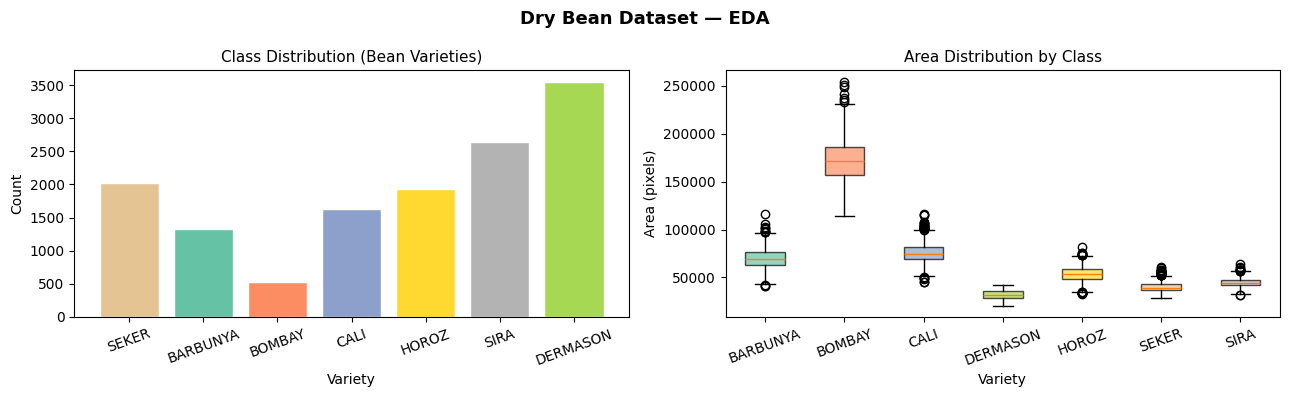

In [18]:
classes = np.unique(y)
palette = plt.cm.Set2(np.linspace(0, 1, len(classes)))
color_map = dict(zip(classes, palette))

# Class distribution bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

counts = Counter(y)
ax1.bar(counts.keys(), counts.values(),
        color=[color_map[c] for c in counts.keys()], edgecolor="white")
ax1.set_title("Class Distribution (Bean Varieties)", fontsize=11)
ax1.set_xlabel("Variety"); ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=20)

# Boxplot of Area by class
data_by_class = [X["Area"][y == c].values for c in classes]
bp = ax2.boxplot(data_by_class, labels=classes, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title("Area Distribution by Class", fontsize=11)
ax2.set_xlabel("Variety"); ax2.set_ylabel("Area (pixels)")
ax2.tick_params(axis="x", rotation=20)

plt.suptitle("Dry Bean Dataset — EDA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

Because there are 16 features in our data, we can apply PCA to reduce our data to two dimensions for better visualization. The PCA 2D scatter (pre-KNN fitting) provides a preview of class structure: Bombay is a clear outlier in the upper-right; the other six classes form overlapping but partially distinguishable clusters. This suggests KNN may struggle the most in the dense overlap region.

---

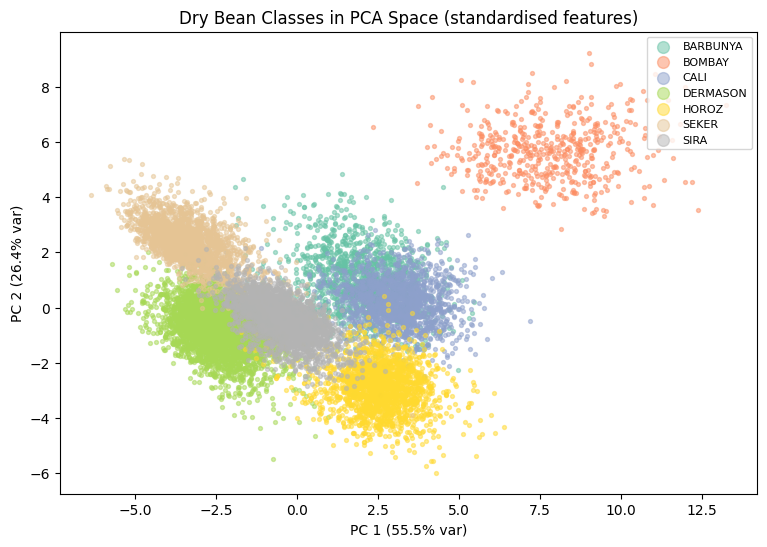

In [19]:
# PCA scatter plot (2D) to visualise class separation
from ml_package import PCA

X_arr_all = X.values.astype(float)
scaler_eda = StandardScaler()
X_scaled_all = scaler_eda.fit_transform(X_arr_all)
pca_eda = PCA(n_components=2)
X_2d = pca_eda.fit_transform(X_scaled_all)

fig, ax = plt.subplots(figsize=(9, 6))
for cls, color in zip(classes, palette):
    mask = y == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=cls, s=8, alpha=0.5, color=color)
ax.set_xlabel(f"PC 1 ({pca_eda.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC 2 ({pca_eda.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Dry Bean Classes in PCA Space (standardised features)", fontsize=12)
ax.legend(markerscale=3, fontsize=8, loc="upper right")
plt.show()


# Data Preprocessing

We build an integer mapping from sorted class names to 0–6, apply it to get integer labels y, then do a stratified 80/20 split. Stratification ensures each class maintains its original proportion in both splits. `StandardScaler` is applied to bring all 16 features to unit variance, which is critical for distance-based methods.

---

In [20]:
# Encode labels as integers
label_to_int = {c: i for i, c in enumerate(classes)}
y = np.array([label_to_int[c] for c in y])

X_arr = X.values.astype(float)

# Use a stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 10888  |  Test: 2723


# Choosing a Value for k

Because running full KNN on over 10,000 training samples is slow, we sub-sample 2,000 training points for the k-selection sweep. For each candidate k in [1, 3, 5, 7, 9, 11, 15, 21], we run 5-fold cross-validation using `k_fold_split`. At each fold, a KNN model is fitted on the fold's training partition and evaluated on its validation partition; the five accuracy values are averaged. Plotting CV accuracy vs. k shows a U-shape: k=1 overfits (low bias, high variance), very large k underfits (high bias, low variance), and the optimal lies in between.

---

In [21]:
from ml_package import k_fold_split

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
val_accs = []

# Use 2000-sample random subset for k-selection speed
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train_s), size=2000, replace=False)
X_sub, y_sub = X_train_s[idx], y_train[idx]

for k in k_values:
    fold_accs = []
    for train_idx, val_idx in k_fold_split(X_sub, y_sub, n_splits=5, random_state=42):
        knn = KNN(k=k, regression=False)
        knn.fit(X_sub[train_idx], y_sub[train_idx])
        preds = knn.predict(X_sub[val_idx])
        fold_accs.append(np.mean(preds == y_sub[val_idx]))
    val_accs.append(np.mean(fold_accs))
    print(f"  k={k:2d}  →  CV accuracy: {np.mean(fold_accs):.4f}")

best_k = k_values[np.argmax(val_accs)]
print(f"\nBest k: {best_k}")


  k= 1  →  CV accuracy: 0.8805
  k= 3  →  CV accuracy: 0.8925
  k= 5  →  CV accuracy: 0.9010
  k= 7  →  CV accuracy: 0.9055
  k= 9  →  CV accuracy: 0.9035
  k=11  →  CV accuracy: 0.9055
  k=15  →  CV accuracy: 0.9025
  k=21  →  CV accuracy: 0.9015

Best k: 7


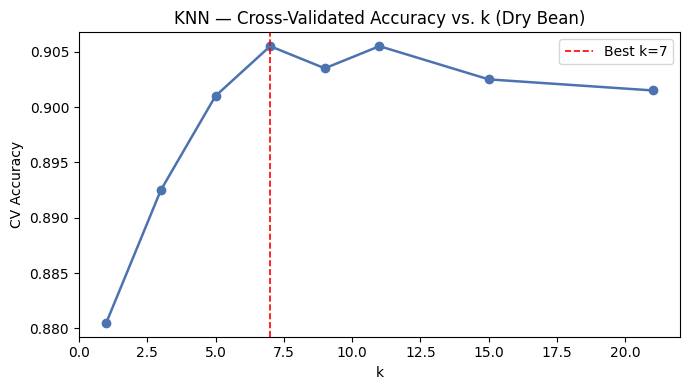

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, val_accs, "o-", color="#4C72B0", linewidth=1.8, markersize=6)
plt.axvline(best_k, color="red", linestyle="--", linewidth=1.2, label=f"Best k={best_k}")
plt.xlabel("k"); plt.ylabel("CV Accuracy")
plt.title("KNN — Cross-Validated Accuracy vs. k (Dry Bean)")
plt.legend()
plt.tight_layout()
plt.show()


---

The k-fold cross-validation sweep determined that the optimal k value for our example is k = 7.

---

## Final Model

Now that we have chosen our value of the nearest neighbors to sample, we can build our final model and evaluate on the test set. The accuracy, precision, recall, and f1_score metrics are all called with `average = 'macro'` to treat each class equally regardless of its sample size. Note that this may take a while to run due to the size of the sample (approx 3.5 minutes).

---

In [25]:
model = KNN(k = 7, regression=False)
model.fit(X_train_s, y_train)

acc = model.accuracy(X_test_s, y_test)
print(f"Test Accuracy (k={7}): {acc:.4f}")
print(f"Precision (macro): {model.precision(X_test_s, y_test, average='macro'):.4f}")
print(f"Recall    (macro): {model.recall(X_test_s, y_test, average='macro'):.4f}")
print(f"F1 Score  (macro): {model.f1_score(X_test_s, y_test, average='macro'):.4f}")


Test Accuracy (k=7): 0.9339
Precision (macro): 0.9457
Recall    (macro): 0.9403
F1 Score  (macro): 0.9428


---

Our KNN model was able to achieve about 94% accuracy on the Dry Bean test data! 

Below is a confusion matrix of the predictions and the actual values.

---

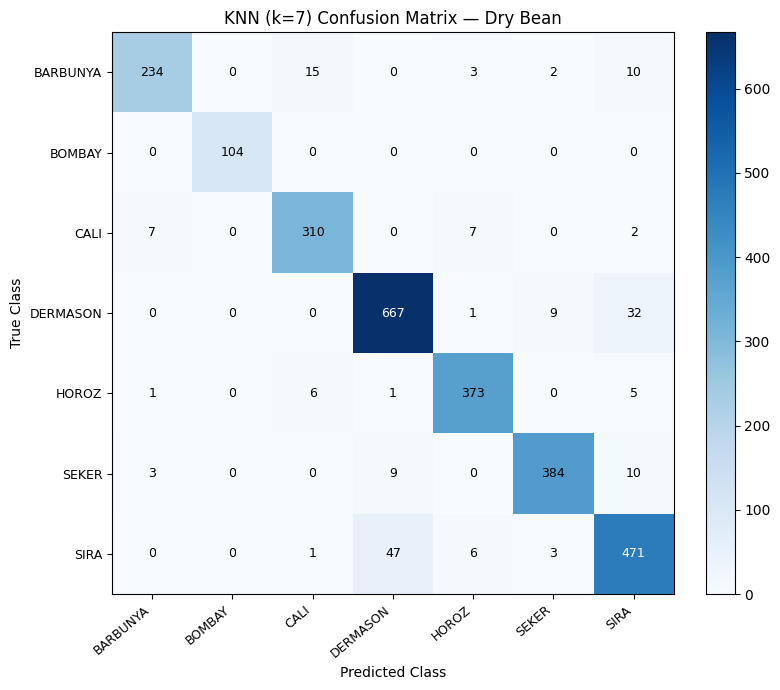

In [26]:
cm = model.confusion_matrix(X_test_s, y_test)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(classes, fontsize=9)
for i in range(len(classes)):
    for j in range(len(classes)):
        color = "white" if cm[i, j] > cm.max() * 0.6 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9, color=color)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
ax.set_title(f"KNN (k={7}) Confusion Matrix — Dry Bean")
plt.tight_layout()
plt.show()


---

Overall, KNN is a powerful non-parametric baseline for this problem. Its main limitation, however, is inference speed, as predicting a single sample requires computing distances to all 10,000+ training samples. For real-time grain sorting systems, this would be impractical without an approximate nearest-neighbour index.

---